# 02 — `trafico_estado`: estado del tráfico por tramos (capa 192)

**Origen.** ArcGIS REST del geoportal del Ajuntament, capa `OPENDATA/Trafico/192`.
Sondeo cada 5 minutos.

**Papel en el TFM.** Es la variable explicativa central. La pregunta de
investigación —cuánto del retraso se explica por la congestión medida aguas abajo
de la ruta— se responde con esta capa o no se responde.

**Trampas que aplican:**

| id | qué |
|----|-----|
| [005](../../.claude/trampas/005-filas-hueco-capa-trafico.md) | ~35 de las 446 filas llegan sin `idtramo`, sin geometría y sin `estado`. No son tramos desconocidos: no son tramos. Denominador real 410 |

Notebook profundo, como el 01.

In [1]:
import sys
from pathlib import Path

# El notebook debe correr tanto abierto desde notebooks/EDA como ejecutado
# desde la raíz del repo (nbclient, CI).
AQUI = Path("notebooks/EDA").resolve() if Path("notebooks/EDA").exists() else Path.cwd()
sys.path.insert(0, str(AQUI))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import eda_utils as eu

eu.estilo()
FUENTE = "trafico_estado"
print("corpus:", eu.dir_fuente(FUENTE))

corpus: C:\Users\oppen\Code\TFM\data\curated\source=trafico_estado


## 1. Censo y esquema

In [2]:
eu.censo(FUENTE)

,valor
métrica,
fuente,trafico_estado
filas,"2,754,220"
ficheros parquet,682
particiones (días),17
tamaño en disco,19.6 MB
ts_utc mínimo,2026-08-15 20:14:39.247821+00:00
ts_utc máximo,2026-08-31 16:40:50.932833+00:00


In [3]:
eu.esquema(FUENTE)

,columna,tipo
0,idtramo,DOUBLE
1,denominacion,VARCHAR
2,estado,DOUBLE
3,fiwareid,VARCHAR
4,lat,DOUBLE
5,lon,DOUBLE
6,n_vertices,DOUBLE
7,ts_utc,TIMESTAMP WITH TIME ZONE
8,ts_ingest_utc,TIMESTAMP WITH TIME ZONE
9,date,DATE


`lat`, `lon` y `n_vertices` salen casi enteramente nulos y **no es un fallo**: la
geometría de los tramos no cambia, así que el colector la baja una vez a
`data/reference/` y luego pide la capa sin ella. Se ve en el perfil de nulos y se
recupera con `eu.geometria("trafico_estado")`.

## 2. Calidad: nulos, cardinalidad, columnas constantes

In [4]:
eu.perfil_nulos(FUENTE)

,columna,nulos,pct_nulos,distintos,constante
6,n_vertices,1478668,53.687,56,False
5,lon,1478668,53.687,412,False
4,lat,1478668,53.687,412,False
3,fiwareid,20055,0.728,409,False
2,estado,6685,0.243,4,False
1,denominacion,0,0.000,410,False
0,idtramo,0,0.000,410,False
7,ts_utc,0,0.000,6685,False
8,ts_ingest_utc,0,0.000,6685,False
9,date,0,0.000,17,False


In [5]:
eu.duplicados(FUENTE, ["ts_ingest_utc", "idtramo"])

,filas,combinaciones_unicas,duplicadas
0,2754220,2740850,13370


## 3. Trampa 005 — el denominador real es 410, no 446

Cada sondeo de la API devuelve del orden de 446 filas, pero unas 35 llegan sin
`idtramo`, sin geometría y sin `estado`. La tentación es tratarlas como "tramos
con estado desconocido" y meterlas en el denominador al calcular el porcentaje de
red congestionada. **No son tramos**: son filas hueco.

**Aquí ya no se ven**, y conviene saber por qué: el colector las descarta en
ingesta (`df = df[df["idtramo"].notna()]` en `parse_trafico_estado`). Lo que llega
a `curated/` está limpio, y eso significa que **este notebook no puede servir de
guardia de la trampa 005** — si mañana alguien quita ese filtro, la tabla de aquí
abajo lo delataría, pero hoy no prueba nada por sí sola.

In [6]:
conteo = eu.sql(
    """
    SELECT count(*) AS filas,
           sum(CASE WHEN idtramo IS NULL THEN 1 ELSE 0 END) AS sin_idtramo,
           sum(CASE WHEN estado IS NULL THEN 1 ELSE 0 END) AS sin_estado,
           count(DISTINCT idtramo) AS tramos_distintos
    FROM {f}
    """,
    f=FUENTE,
)
print("geometría en reference/:", len(eu.geometria(FUENTE)), "tramos")
conteo

geometría en reference/: 410 tramos


,filas,sin_idtramo,sin_estado,tramos_distintos
0,2754220,0.000,"6,685.000",410


In [7]:
por_sondeo = eu.sql(
    """
    SELECT ts_ingest_utc,
           count(*) AS filas,
           count(idtramo) AS con_idtramo,
           count(estado) AS con_estado
    FROM {f} GROUP BY 1
    """,
    f=FUENTE,
)
por_sondeo[["filas", "con_idtramo", "con_estado"]].describe().round(1)

,filas,con_idtramo,con_estado
count,"6,685.000","6,685.000","6,685.000"
mean,412.000,412.000,411.000
std,0.000,0.000,0.000
min,412.000,412.000,411.000
25%,412.000,412.000,411.000
50%,412.000,412.000,411.000
75%,412.000,412.000,411.000
max,412.000,412.000,411.000


**Cada sondeo trae 412 filas pero solo 410 tramos distintos.** No es ruido
aleatorio: la diferencia es exactamente la misma en los 6.685 sondeos, así que hay
tramos que la fuente publica **por duplicado siempre**. Un `join` por `idtramo`
contra la geometría, o contra las posiciones de bus, multiplicaría esas filas sin
avisar.

In [8]:
eu.sql(
    """
    WITH d AS (
        SELECT ts_ingest_utc, idtramo, count(*) AS veces
        FROM {f} GROUP BY 1, 2 HAVING count(*) > 1
    )
    SELECT idtramo,
           count(*) AS sondeos_en_que_se_duplica,
           max(veces) AS copias_por_sondeo
    FROM d GROUP BY 1 ORDER BY 2 DESC
    """,
    f=FUENTE,
)

,idtramo,sondeos_en_que_se_duplica,copias_por_sondeo
0,216.000,6685,2
1,211.000,6685,2


Dos tramos duplicados en todos y cada uno de los sondeos. Es una propiedad
estable de la fuente, no una incidencia: **`idtramo` no es clave** en esta capa, y
lo que hay que usar como clave es `(ts_ingest_utc, idtramo)` con deduplicación
explícita.

## 4. La variable `estado`

Códigos tal como los publica el Ajuntament: `0` fluido, `1` denso, `2`
congestionado, `3` cortado, `4` sin datos, y la serie `5-9` repite lo mismo para
pasos inferiores.

In [9]:
est = eu.sql(
    "SELECT estado, count(*) AS filas FROM {f} GROUP BY 1 ORDER BY 2 DESC", f=FUENTE
)
est["etiqueta"] = est["estado"].map(lambda v: eu.ESTADO_TRAFICO.get(v, "NULO") if pd.notna(v) else "NULO")
est["pct"] = 100 * est["filas"] / est["filas"].sum()
est.round(3)

,estado,filas,etiqueta,pct
0,0.000,2705250,fluido,98.222
1,3.000,41444,cortado,1.505
2,NaN,6685,NULO,0.243
3,1.000,779,denso,0.028
4,2.000,62,congestionado,0.002


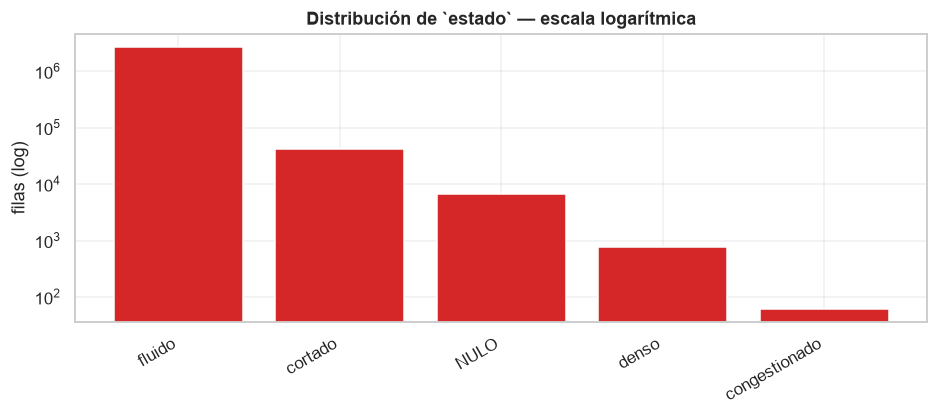

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(est["etiqueta"], est["filas"], color=eu.PALETA[FUENTE])
ax.set_yscale("log")
ax.set_ylabel("filas (log)")
ax.set_title("Distribución de `estado` — escala logarítmica")
plt.xticks(rotation=30, ha="right")
plt.show()

**El desequilibrio no es "fuerte": es casi total.** `fluido` se lleva más del 98 %
de las filas. `cortado` (1,5 %) aparece **cincuenta veces más** que `denso` y
`congestionado` juntos, que no llegan al 0,03 %.

Ese orden de magnitud es la señal de alarma: en una red urbana real, "denso" tiene
que ser mucho más frecuente que "cortado". Que salga al revés dice que `3` no
significa lo que su nombre sugiere. Se comprueba en la sección 6.

## 5. Sensores muertos: tramos que nunca cambian de estado

In [11]:
variacion = eu.sql(
    """
    SELECT idtramo,
           any_value(denominacion) AS denominacion,
           count(*) AS observaciones,
           count(DISTINCT estado) AS estados_distintos,
           avg(estado) AS estado_medio
    FROM {f} WHERE idtramo IS NOT NULL GROUP BY 1
    """,
    f=FUENTE,
)
muertos = variacion[variacion["estados_distintos"] <= 1]
print(f"{len(muertos)} de {len(variacion)} tramos no cambian NUNCA de estado "
      f"({100 * len(muertos) / len(variacion):.1f} %)")
muertos.sort_values("observaciones", ascending=False).head(15)

333 de 410 tramos no cambian NUNCA de estado (81.2 %)


,idtramo,denominacion,observaciones,estados_distintos,estado_medio
2,326.000,JOAQUIN BALLESTER HACIA PÍO XII,6685,1,0.000
3,166.000,AV. DE LA PLATA HACIA AUSIAS MARCH,6685,1,0.000
4,183.000,MAESTRO RODRIGO (DE GRAL. AVILES A CAMP DE TURIA),6685,1,0.000
5,48.000,GENERAL AVILÉS (DE MTRO. RODRIGO A PÍO XII),6685,1,0.000
7,504.000,AV. AMADO GRANELL MESADO (De Av- Antonio Ferra...,6685,1,0.000
8,531.000,PASEO DE LA ALAMEDA (De C./ Ibiza a Plaza Fall...,6685,1,0.000
9,351.000,BURJASSOT (DE PESET ALEIXANDRE A BENICALAP),6685,1,0.000
10,435.000,CAMP DEL TURIA (DE NICASIO BENLLOCH A CORTES V...,6685,1,0.000
11,245.000,AV. DEL PUERTO (DE SERRERÍA A J.J. DÓMINE),6685,1,0.000
12,310.000,PASO INFERIOR GUILLEM DE CASTRO - ANGEL GUIMERA,6685,1,0.000


**Cuatro de cada cinco tramos no cambian de estado ni una sola vez en dieciséis
días.** Eso no es "algunos sensores muertos": es que la capa 192, como fuente de
variación, es mucho más pequeña de lo que aparenta. El censo dice 410 tramos; la
señal vive en 77.

Conviene medir con cuánta señal se queda uno realmente antes de construir nada
encima.

In [12]:
señal = eu.sql(
    """
    WITH t AS (
        SELECT idtramo,
               count(DISTINCT estado) AS estados,
               sum(CASE WHEN estado IN (1, 2) THEN 1 ELSE 0 END) AS obs_congestion,
               sum(CASE WHEN estado = 3 THEN 1 ELSE 0 END) AS obs_cortado
        FROM {f} WHERE idtramo IS NOT NULL AND estado IS NOT NULL GROUP BY 1
    )
    SELECT count(*) AS tramos,
           sum(CASE WHEN estados > 1 THEN 1 ELSE 0 END) AS varian_alguna_vez,
           sum(CASE WHEN obs_congestion > 0 THEN 1 ELSE 0 END) AS alcanzan_denso_o_congestionado,
           sum(CASE WHEN obs_cortado > 0 THEN 1 ELSE 0 END) AS alcanzan_cortado
    FROM t
    """,
    f=FUENTE,
)
señal

,tramos,varian_alguna_vez,alcanzan_denso_o_congestionado,alcanzan_cortado
0,409,77.000,63.000,22.000


El número que importa es **cuántos tramos llegan a estar `denso` o
`congestionado` alguna vez**, porque es el único estado que describe congestión de
tráfico propiamente dicha. Si ese número es pequeño, la variable explicativa
central del TFM tiene mucha menos cobertura de la que promete el censo de 410
tramos, y hay que decirlo en la memoria antes de que lo pregunte el tribunal.

## 6. Matriz de transición entre estados

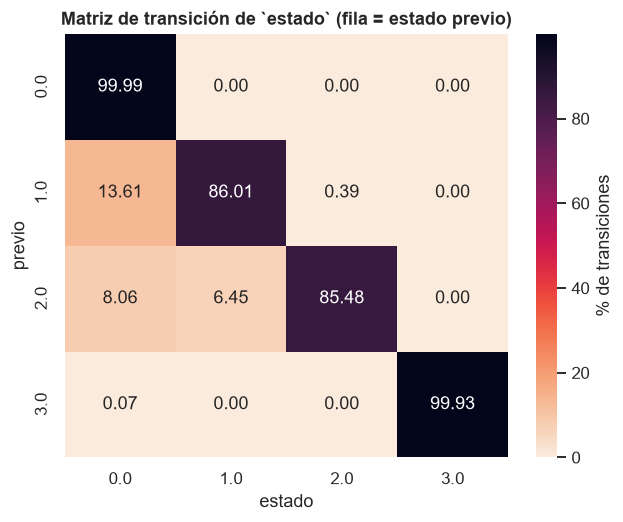

estado,0.000,1.000,2.000,3.000
previo,,,,
0.000,99.995,0.004,0.000,0.001
1.000,13.607,86.008,0.385,0.000
2.000,8.065,6.452,85.484,0.000
3.000,0.068,0.000,0.000,99.932


In [13]:
trans = eu.sql(
    """
    WITH s AS (
        SELECT idtramo, ts_ingest_utc, estado,
               lag(estado) OVER (PARTITION BY idtramo ORDER BY ts_ingest_utc) AS previo
        FROM {f} WHERE idtramo IS NOT NULL AND estado IS NOT NULL
    )
    SELECT previo, estado, count(*) AS n
    FROM s WHERE previo IS NOT NULL GROUP BY 1, 2
    """,
    f=FUENTE,
)
m = trans.pivot(index="previo", columns="estado", values="n").fillna(0)
m_pct = 100 * m.div(m.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(m_pct, annot=True, fmt=".2f", cmap="rocket_r", ax=ax, cbar_kws={"label": "% de transiciones"})
ax.set_title("Matriz de transición de `estado` (fila = estado previo)")
plt.show()
m_pct.round(3)

Tres cosas se leen en esta matriz, y la tercera es la importante:

- **el estado es extremadamente persistente**: la diagonal se lleva prácticamente
  todo. Una feature "estado actual del tramo" está tan autocorrelacionada que un
  modelo puede parecer bueno limitándose a copiar el valor anterior. Es la razón
  de que el baseline de persistencia sea obligatorio y de que sea el rival serio;
- **si el estado casi no cambia en 5 minutos, sondear más rápido no aportaría
  información**: el límite no es la cadencia del colector, es la del fenómeno;
- **`3` es un estado casi absorbente.** Entra y no sale: su probabilidad de
  permanencia es aún mayor que la de `fluido`, y sus transiciones hacia `1` o `2`
  son cero. Un corte de tráfico real dura minutos u horas y vuelve; esto no
  vuelve. **`3` no es "cortado" en el sentido de incidencia: es una vía cerrada de
  forma permanente** — obras, vía de servicio clausurada, tramo fuera de uso.

La consecuencia es concreta y hay que aplicarla en `features.py`: una feature
"porcentaje de red no fluida" que meta el `3` en el numerador **no mide
congestión, mide obras**. La congestión son los estados `1` y `2`, y son
rarísimos.

## 7. Tramos más congestionados

In [14]:
cong = eu.sql(
    """
    SELECT idtramo,
           any_value(denominacion) AS denominacion,
           count(*) AS observaciones,
           100.0 * sum(CASE WHEN estado IN (1, 2) THEN 1 ELSE 0 END) / count(*) AS pct_congestion,
           100.0 * sum(CASE WHEN estado = 3 THEN 1 ELSE 0 END) / count(*) AS pct_cortado
    FROM {f} WHERE idtramo IS NOT NULL AND estado IS NOT NULL
    GROUP BY 1 HAVING count(*) > 1000
    ORDER BY pct_congestion DESC
    """,
    f=FUENTE,
)
cong.head(20).round(3)

,idtramo,denominacion,observaciones,pct_congestion,pct_cortado
0,276.000,PASO INFERIOR CATALUÑA DE ENTRADA,6685,2.139,0.000
1,30.000,FERRAN EL CATOLIC CAP A PONT DE LAS GLORIES VA...,6685,1.227,0.000
2,275.000,PUENTE DEL ASSUT DE L'OR HACIA ANTONIO FERRANDIS,6685,0.628,0.000
3,1.000,AV. CATALUNYA D'ENTRADA,6685,0.539,0.000
4,341.000,AUSIAS MARCH (DE A. FERRANDIS A V-31),6685,0.359,0.000
5,316.000,PASO INFERIOR MENÉNDEZ PIDAL - TIRSO DE MOLINA,6685,0.314,0.000
6,178.000,PÍO BAROJA (DE GRAL. AVILÉS A MANUEL DE FALLA),6685,0.314,0.000
7,403.000,MENORCA HACIA ALAMEDA,6685,0.299,0.000
8,158.000,RUSSAFA,6685,0.299,0.000
9,414.000,VÍA DE SERVICIO DE HNOS. MACHADO HACIA CNO. MO...,6685,0.269,0.000


Separadas las dos columnas, se ve lo que la métrica agregada escondía: los tramos
que encabezan `pct_cortado` con el 100 % son **vías de servicio permanentemente
cerradas**, no puntos negros de tráfico. Los que de verdad se congestionan
aparecen en `pct_congestion`, con porcentajes de un orden de magnitud mucho menor.

Esta segunda lista es la que hay que cruzar con el trazado de las líneas de bus:
**si los tramos que se congestionan no están en el recorrido de ninguna línea, la
hipótesis del TFM no tiene por dónde manifestarse**. Es una comprobación de
viabilidad, no un adorno descriptivo, y es exactamente lo que hace
`analysis/diagnose.py`.

## 8. Perfil temporal de la congestión

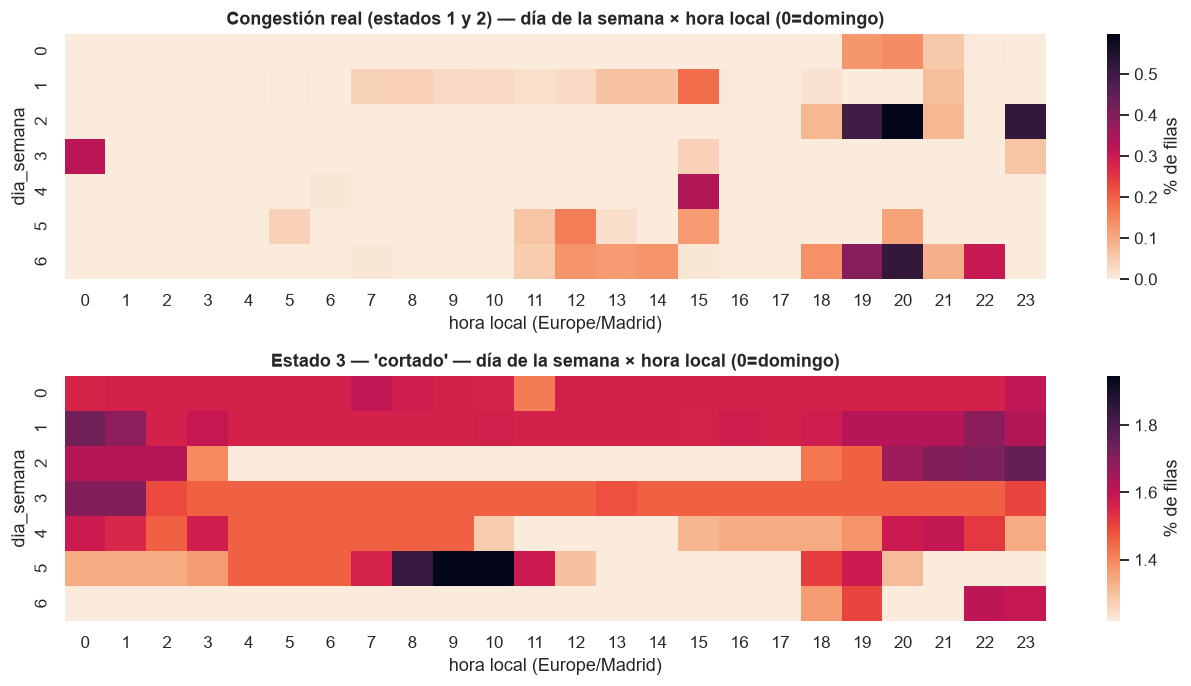

In [15]:
horario = eu.sql(
    """
    SELECT hour(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS hora_local,
           dayofweek(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS dia_semana,
           100.0 * sum(CASE WHEN estado IN (1, 2) THEN 1 ELSE 0 END) / count(*) AS pct_congestion,
           100.0 * sum(CASE WHEN estado = 3 THEN 1 ELSE 0 END) / count(*) AS pct_cortado
    FROM {f} WHERE estado IS NOT NULL GROUP BY 1, 2
    """,
    f=FUENTE,
)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6.4))
for ax, col, titulo in (
    (a1, "pct_congestion", "Congestión real (estados 1 y 2)"),
    (a2, "pct_cortado", "Estado 3 — 'cortado'"),
):
    sns.heatmap(
        horario.pivot(index="dia_semana", columns="hora_local", values=col),
        cmap="rocket_r",
        ax=ax,
        cbar_kws={"label": "% de filas"},
    )
    ax.set_title(f"{titulo} — día de la semana × hora local (0=domingo)")
    ax.set_xlabel("hora local (Europe/Madrid)")
fig.tight_layout()
plt.show()

Los dos mapas dicen cosas opuestas y por eso van separados:

- **la congestión real (1 y 2) tiene patrón horario**: se concentra en las horas
  punta de los días laborables y desaparece de madrugada y el fin de semana. Esa
  es la **prueba de sanidad de la fuente**: si no saliera, la capa estaría
  publicando ruido y no habría nada que fusionar;
- **el `3` es plano**: la misma proporción a las cuatro de la mañana del domingo
  que a las ocho de un martes. Un fenómeno de tráfico no se comporta así. Es la
  confirmación independiente de que `3` marca cierres permanentes, y de que
  meterlo en una feature de congestión añadiría una constante, no información.

## 9. Geometría: dónde están los tramos

In [16]:
geo = eu.geometria(FUENTE)
print(f"{len(geo)} tramos con geometría en data/reference/")
geo.head()

410 tramos con geometría en data/reference/


,idtramo,denominacion,fiwareid,lat,lon,geom_wkt
0,336.000,MARIA CRISTINA,EstadoTrafico_336,39.472,-0.377,"LINESTRING (-0.376922 39.472193, -0.377694 39...."
1,335.000,PLAÇA DEL AJUNTAMENT,EstadoTrafico_335,39.469,-0.377,"LINESTRING (-0.376811 39.469243, -0.375623 39...."
2,214.000,JUAN XXIII HACIA HNOS. MACHADO,EstadoTrafico_214,39.490,-0.382,"LINESTRING (-0.382079 39.490474, -0.384647 39...."
3,270.000,PASEO DE LA ALAMEDA (DE PLAZA ZARAGOZA A EDUAR...,EstadoTrafico_270,39.468,-0.361,"LINESTRING (-0.360867 39.468181, -0.358845 39...."
4,38.000,COLÓN,EstadoTrafico_38,39.472,-0.369,"LINESTRING (-0.368683 39.471901, -0.369292 39...."


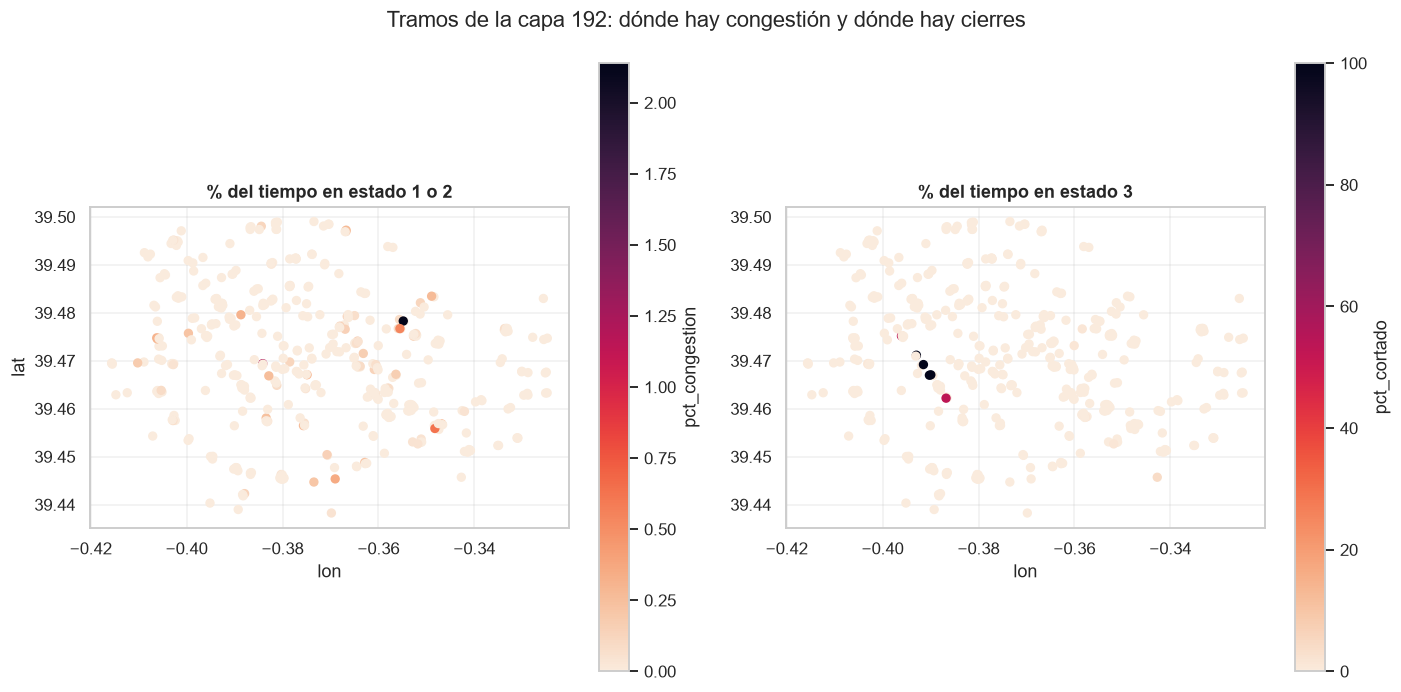

In [17]:
g = geo.merge(cong[["idtramo", "pct_congestion", "pct_cortado"]], on="idtramo", how="left")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 6.4))
for ax, col, titulo in (
    (a1, "pct_congestion", "% del tiempo en estado 1 o 2"),
    (a2, "pct_cortado", "% del tiempo en estado 3"),
):
    sc = ax.scatter(g["lon"], g["lat"], c=g[col], cmap="rocket_r", s=26)
    fig.colorbar(sc, ax=ax, label=col)
    ax.set_aspect("equal")
    ax.set_xlabel("lon")
    ax.set_title(titulo)
a1.set_ylabel("lat")
fig.suptitle("Tramos de la capa 192: dónde hay congestión y dónde hay cierres")
fig.tight_layout()
plt.show()

**La cobertura espacial de la capa es el límite real del estudio.** Los tramos se
concentran en el centro y los grandes ejes; un autobús que circula por una zona
sin tramos instrumentados no tiene congestión medible aguas abajo, por mucho que
se retrase. Al reportar resultados hay que separar las líneas cubiertas de las que
no lo están, en vez de promediar sobre todas y diluir el efecto.

## 10. Hallazgos

1. **`estado = 3` no es congestión, es cierre permanente.** Tres evidencias
   independientes: es casi absorbente en la matriz de transición, no tiene patrón
   horario ni semanal, y los tramos que lo exhiben al 100 % son vías de servicio.
   **Meterlo en una feature de "red no fluida" mide obras, no tráfico.** Es el
   hallazgo más importante de este notebook y afecta directamente a `features.py`.
2. **La congestión real (estados 1 y 2) es rarísima**: no llega al 0,03 % de las
   filas. La variable explicativa central del TFM es un evento raro, y eso cambia
   cómo hay que construirla —agregados y ventanas temporales, no el estado
   instantáneo de un tramo— y cómo hay que evaluarla.
3. **Cuatro de cada cinco tramos no cambian nunca de estado.** El censo dice 410,
   pero solo 77 varían alguna vez y apenas 63 llegan a estar `denso` o
   `congestionado` en dieciséis días. **63 es el tamaño real de la fuente** para lo
   que el TFM necesita, y es ese número el que hay que declarar en la memoria.
4. **La congestión real sí tiene patrón horario laborable.** Es la prueba de que
   la fuente mide algo y de que la hipótesis tiene por dónde manifestarse.
5. **`idtramo` no es clave**: dos tramos vienen duplicados en todos los sondeos.
   La clave es `(ts_ingest_utc, idtramo)` con deduplicación explícita.
6. **El estado es muy persistente entre sondeos.** El baseline de persistencia es
   el rival serio, y sondear más rápido no añadiría información.
7. **La trampa 005 está resuelta aguas arriba**, en `parse_trafico_estado`. Este
   notebook no la guarda: solo la vería reaparecer si alguien quitara el filtro.
8. **La geometría vive en `data/reference/`**, y su cobertura espacial acota qué
   líneas de bus pueden siquiera exhibir el efecto que busca el TFM.